# **Project Name**    - Brain Tumour Detection System



##### **Project Type**    - Classification
##### **Contribution**    - Individual
##### **Team Member 1 -**  Tanuj Jain


# **Project Summary -**

I developed a deep learning-based solution to classify brain MRI scans into four categories: Glioma, Meningioma, Pituitary, and No Tumor. The project began with thorough data exploration and preprocessing, followed by the design of a Custom CNN model and comparison with pretrained architectures like VGG19 and ResNet50 through transfer learning. Data augmentation techniques were applied to improve generalization, and performance was tracked using metrics such as accuracy, precision, and confusion matrix. The Custom CNN outperformed the pretrained models in accuracy and consistency, making it the best candidate for deployment. I deployed the final model using Streamlit, enabling a real-time interactive web application for MRI image classification. This solution demonstrates the power of deep learning in healthcare, particularly in assisting radiologists with faster and more accurate brain tumor detection.

# **GitHub Link -** [Click here to view the model on GitHub](https://github.com/TANUJ0751/Brain-Tumour-Detection)


# Deployed Project Link - [Click here to view the Deployed Project](https://btd-by-tanujjain.streamlit.app/)


# **Problem Statement**

The increasing prevalence of brain tumors and the time-intensive nature of manual diagnosis create a critical need for automated tools in medical imaging. This project aims to develop a deep learning-based system that classifies brain MRI images into four categories — Glioma, Meningioma, Pituitary, and No Tumor. The objective is to build a custom Convolutional Neural Network (CNN) model and leverage transfer learning techniques to enhance classification accuracy. The final solution is deployed via a Streamlit web application to enable real-time predictions and improve accessibility for healthcare professionals.

## ***1. Know Your Data***

### Import Libraries

In [27]:
import tensorflow as tf
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications import ResNet50

### Define paths

In [2]:

dataset_dir = './Tumour'
img_size = (224, 224)
batch_size = 16

### Dataset Loading

In [3]:



train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_dir, 'train'),
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical'  # or 'int'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_dir, 'valid'),
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_dir, 'test'),
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical'
)

Found 1695 files belonging to 4 classes.


I0000 00:00:1753362554.643811    4471 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2248 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


Found 502 files belonging to 4 classes.
Found 246 files belonging to 4 classes.


### Dataset Information

In [4]:
class_names = train_ds.class_names
print("Classes:", class_names)

# Count images per class in train set
class_counts = {cls: 0 for cls in class_names}
for images, labels in train_ds.unbatch():
    class_counts[class_names[tf.argmax(labels)]] += 1

print("Class distribution in train set:", class_counts)


Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Class distribution in train set: {'glioma': 564, 'meningioma': 358, 'no_tumor': 335, 'pituitary': 438}


2025-07-24 18:39:19.151939: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### What did you know about your dataset?

The dataset is already divided into train , test and validation parts. The images are total of 4 categories which are (glioma, meningioma, no_tumour, pituitary)

### Dataset First View

2025-07-24 18:39:19.321778: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


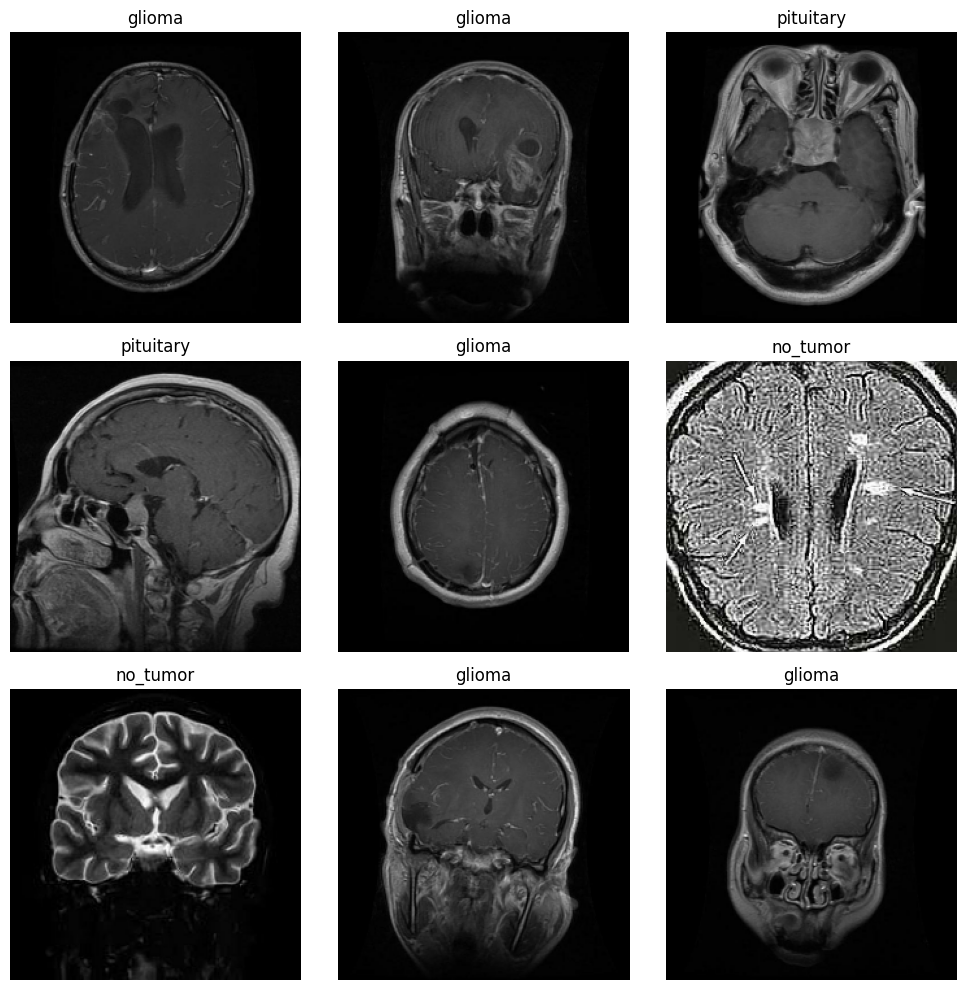

In [5]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[tf.argmax(labels[i])])
        plt.axis("off")
plt.tight_layout()
plt.show()

for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Pixel value range:", images[0].numpy().min(), "-", images[0].numpy().max())


### EDA (Class Distribution)

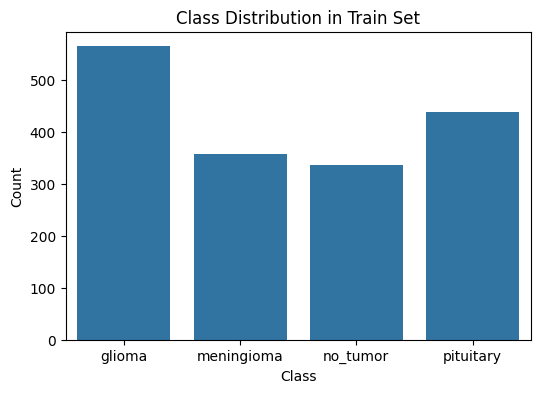

In [6]:


df = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])
plt.figure(figsize=(6,4))
sns.barplot(x='Class', y='Count', data=df)
plt.title("Class Distribution in Train Set")
plt.show()


Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Class distribution in test set: {'glioma': 564, 'meningioma': 358, 'no_tumor': 335, 'pituitary': 438}


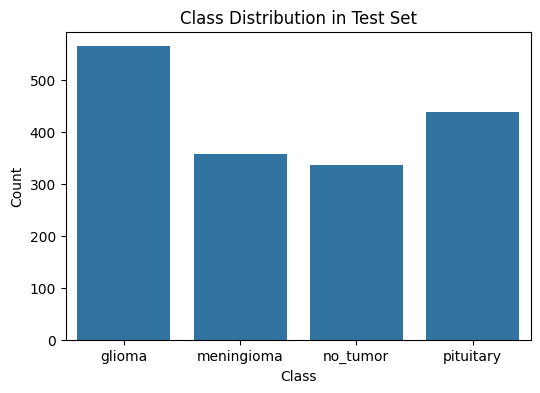

In [7]:
class_names = test_ds.class_names
print("Classes:", class_names)

# Count images per class in train set
class_counts = {cls: 0 for cls in class_names}
for images, labels in train_ds.unbatch():
    class_counts[class_names[tf.argmax(labels)]] += 1

print("Class distribution in test set:", class_counts)
df = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])
plt.figure(figsize=(6,4))
sns.barplot(x='Class', y='Count', data=df)
plt.title("Class Distribution in Test Set")
plt.show()

Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Class distribution in Validation set: {'glioma': 564, 'meningioma': 358, 'no_tumor': 335, 'pituitary': 438}


2025-07-24 18:39:25.007603: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


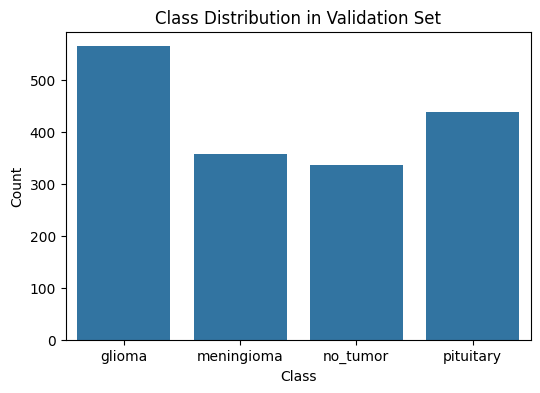

In [8]:
class_names = val_ds.class_names
print("Classes:", class_names)

# Count images per class in train set
class_counts = {cls: 0 for cls in class_names}
for images, labels in train_ds.unbatch():
    class_counts[class_names[tf.argmax(labels)]] += 1

print("Class distribution in Validation set:", class_counts)
df = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])
plt.figure(figsize=(6,4))
sns.barplot(x='Class', y='Count', data=df)
plt.title("Class Distribution in Validation Set")
plt.show()

### Data Preprocessing

In [9]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [11]:
# Defining Epoch
epochs=30

In [ ]:
num_classes = len(class_names)

### Model 1 : Custom CNN Model

In [ ]:


model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=img_size + (3,)),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.summary()

In [12]:
#Compiling The Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
# Training The Model

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)


Epoch 1/30


I0000 00:00:1753362569.841681    4594 service.cc:152] XLA service 0x7fb388004c30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1753362569.841758    4594 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
2025-07-24 18:39:29.886755: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1753362570.237561    4594 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-07-24 18:39:30.860867: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.9 = (f32[16,32,222,222]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,3,224,224]{3,2,1,0} %bitcast.4904, f32[32,3,3,3]{3,2,1,0} %bitcast.4713, f32[32]{0} %bitcast.5246), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$con

  3/106 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.2257 - loss: 1.4488  

I0000 00:00:1753362575.531141    4594 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 67/106 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.5093 - loss: 1.1605

2025-07-24 18:39:38.811575: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.9 = (f32[15,32,222,222]{3,2,1,0}, u8[0]{0}) custom-call(f32[15,3,224,224]{3,2,1,0} %bitcast.4904, f32[32,3,3,3]{3,2,1,0} %bitcast.4713, f32[32]{0} %bitcast.5246), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_1/conv2d_1/convolution" source_file="/home/tanuj/jupyter_project/mybase/lib/python3.10/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2025-07-24 18:39:38.922984: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted po

105/106 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.5574 - loss: 1.0702

2025-07-24 18:39:44.323366: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.9 = (f32[16,32,222,222]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,3,224,224]{3,2,1,0} %bitcast.540, f32[32,3,3,3]{3,2,1,0} %bitcast.547, f32[32]{0} %bitcast.549), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_1/conv2d_1/convolution" source_file="/home/tanuj/jupyter_project/mybase/lib/python3.10/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kRelu","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2025-07-24 18:39:44.415429: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted poten

106/106 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - accuracy: 0.5594 - loss: 1.0662 - val_accuracy: 0.8486 - val_loss: 0.5035
Epoch 2/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.8305 - loss: 0.4942 - val_accuracy: 0.8825 - val_loss: 0.3942
Epoch 3/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.9072 - loss: 0.2878 - val_accuracy: 0.9044 - val_loss: 0.2840
Epoch 4/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.9332 - loss: 0.2045 - val_accuracy: 0.9143 - val_loss: 0.2710
Epoch 5/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.9494 - loss: 0.1645 - val_accuracy: 0.9243 - val_loss: 0.2546
Epoch 6/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.9553 - loss: 0.1211 - val_accuracy: 0.9303 - val_loss: 0.2626
Epoch 7/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.9722 - loss: 0.0715 - val_accuracy: 0.9283 - val_loss: 0.2947
Epoch 8/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.9756 - loss: 0.0802 - val_accuracy: 0.9

In [14]:

# Evaluating The Model
test_loss, test_acc = model.evaluate(test_ds)
print(f"\n Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9406 - loss: 0.4620

 Test Accuracy: 0.9309, Test Loss: 0.5253


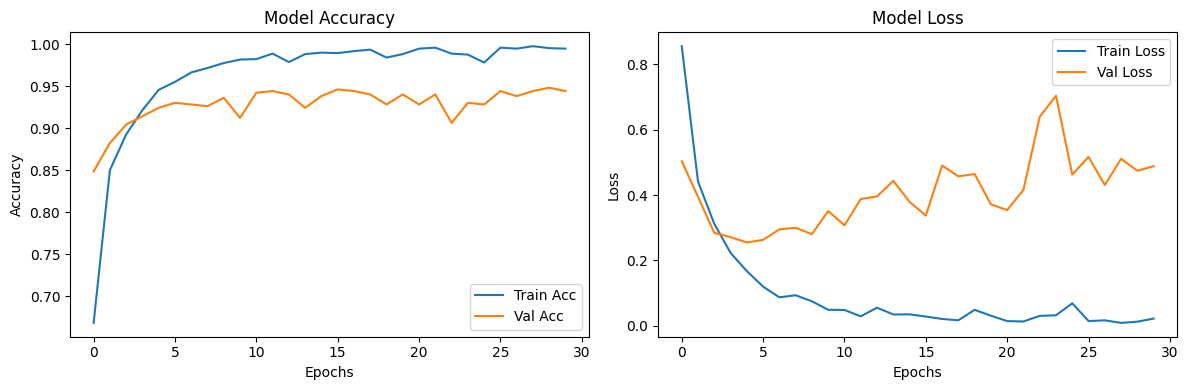

In [15]:
#Ploting Accuracy and Loss Graph Throughtout the Training

plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')

plt.tight_layout()
plt.show()


In [16]:
# Making a Function for Creating Transfer Learning Model

def build_transfer_model(base_model, num_classes):
    base_model.trainable = False  # Freeze base

    model = tf.keras.Sequential([
        tf.keras.layers.Rescaling(1./255, input_shape=(224, 224, 3)),
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


### Model-2: VGG19 Model

In [17]:
#Training The Model

print("\n Training VGG19 Model")
vgg_base = VGG19(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

vgg_model = build_transfer_model(vgg_base, num_classes) 

vgg_history = vgg_model.fit(train_ds, validation_data=val_ds, epochs=epochs)




 Training VGG19 Model
Epoch 1/30


2025-07-24 18:42:09.860075: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.48 = (f32[16,64,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,3,224,224]{3,2,1,0} %bitcast.3665, f32[64,3,3,3]{3,2,1,0} %bitcast.3672, f32[64]{0} %bitcast.3674), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_1_1/vgg19_1/block1_conv1_1/convolution" source_file="/home/tanuj/jupyter_project/mybase/lib/python3.10/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kRelu","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2025-07-24 18:42:09.966853: I external/local_xla/xla/service/gpu/autotuning/conv_algori

  3/106 ━━━━━━━━━━━━━━━━━━━━ 18s 179ms/step - accuracy: 0.1840 - loss: 1.8981

2025-07-24 18:42:18.204980: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.48 = (f32[15,64,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[15,3,224,224]{3,2,1,0} %bitcast.3665, f32[64,3,3,3]{3,2,1,0} %bitcast.3672, f32[64]{0} %bitcast.3674), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_1_1/vgg19_1/block1_conv1_1/convolution" source_file="/home/tanuj/jupyter_project/mybase/lib/python3.10/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kRelu","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2025-07-24 18:42:18.316015: I external/local_xla/xla/service/gpu/autotuning/conv_algori

106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.3711 - loss: 1.4067

2025-07-24 18:42:50.677965: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.48 = (f32[6,64,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[6,3,224,224]{3,2,1,0} %bitcast.901, f32[64,3,3,3]{3,2,1,0} %bitcast.908, f32[64]{0} %bitcast.910), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_1_1/vgg19_1/block1_conv1_1/convolution" source_file="/home/tanuj/jupyter_project/mybase/lib/python3.10/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kRelu","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2025-07-24 18:42:50.793644: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_p

106/106 ━━━━━━━━━━━━━━━━━━━━ 48s 365ms/step - accuracy: 0.3721 - loss: 1.4049 - val_accuracy: 0.6215 - val_loss: 1.0148
Epoch 2/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 24s 226ms/step - accuracy: 0.6432 - loss: 0.9566 - val_accuracy: 0.7072 - val_loss: 0.8267
Epoch 3/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 25s 235ms/step - accuracy: 0.7067 - loss: 0.8131 - val_accuracy: 0.7470 - val_loss: 0.7191
Epoch 4/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 25s 234ms/step - accuracy: 0.7270 - loss: 0.7336 - val_accuracy: 0.7649 - val_loss: 0.6379
Epoch 5/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 24s 225ms/step - accuracy: 0.7439 - loss: 0.6678 - val_accuracy: 0.7769 - val_loss: 0.6010
Epoch 6/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 25s 233ms/step - accuracy: 0.7727 - loss: 0.5915 - val_accuracy: 0.7849 - val_loss: 0.5673
Epoch 7/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 25s 236ms/step - accuracy: 0.7772 - loss: 0.5842 - val_accuracy: 0.8028 - val_loss: 0.5279
Epoch 8/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 25s 236ms/step - accuracy: 0.7959 - loss: 0.5370 - val

In [18]:
# Testing VGG19 Model
vgg_test_loss, vgg_test_acc = vgg_model.evaluate(test_ds)
print(f"✅ VGG19 Test Accuracy: {vgg_test_acc:.4f}")


16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 218ms/step - accuracy: 0.8847 - loss: 0.4580
✅ VGG19 Test Accuracy: 0.8740


### Model-3: ResNet50 Model

In [19]:
print("\n Training ResNet50 Model")
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
resnet_model = build_transfer_model(resnet_base, num_classes)

resnet_history = resnet_model.fit(train_ds, validation_data=val_ds, epochs=epochs)




 Training ResNet50 Model
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 29s 0us/step
Epoch 1/30


2025-07-24 18:55:31.514923: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.162 = (f32[16,64,56,56]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,64,56,56]{3,2,1,0} %bitcast.7609, f32[64,64,3,3]{3,2,1,0} %bitcast.7616, f32[64]{0} %bitcast.7618), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_2_1/resnet50_1/conv2_block1_2_conv_1/convolution" source_file="/home/tanuj/jupyter_project/mybase/lib/python3.10/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2025-07-24 18:55:32.039725: I external/local_xla/xla/service/gpu/autotuning/co

 27/106 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.2975 - loss: 1.5661

2025-07-24 18:55:39.798688: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.162 = (f32[15,64,56,56]{3,2,1,0}, u8[0]{0}) custom-call(f32[15,64,56,56]{3,2,1,0} %bitcast.7609, f32[64,64,3,3]{3,2,1,0} %bitcast.7616, f32[64]{0} %bitcast.7618), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_2_1/resnet50_1/conv2_block1_2_conv_1/convolution" source_file="/home/tanuj/jupyter_project/mybase/lib/python3.10/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2025-07-24 18:55:40.307354: I external/local_xla/xla/service/gpu/autotuning/co

106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.3344 - loss: 1.4555

2025-07-24 18:55:55.222717: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.162 = (f32[6,64,56,56]{3,2,1,0}, u8[0]{0}) custom-call(f32[6,64,56,56]{3,2,1,0} %bitcast.4845, f32[64,64,3,3]{3,2,1,0} %bitcast.4852, f32[64]{0} %bitcast.4854), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_2_1/resnet50_1/conv2_block1_2_conv_1/convolution" source_file="/home/tanuj/jupyter_project/mybase/lib/python3.10/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2025-07-24 18:55:55.587481: I external/local_xla/xla/service/gpu/autotuning/conv

106/106 ━━━━━━━━━━━━━━━━━━━━ 36s 221ms/step - accuracy: 0.3349 - loss: 1.4545 - val_accuracy: 0.4582 - val_loss: 1.2055
Epoch 2/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.4868 - loss: 1.2044 - val_accuracy: 0.5618 - val_loss: 1.1120
Epoch 3/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.5593 - loss: 1.1176 - val_accuracy: 0.6633 - val_loss: 1.0530
Epoch 4/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - accuracy: 0.5624 - loss: 1.0943 - val_accuracy: 0.6414 - val_loss: 1.0079
Epoch 5/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - accuracy: 0.5944 - loss: 1.0261 - val_accuracy: 0.6574 - val_loss: 0.9307
Epoch 6/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.6008 - loss: 1.0179 - val_accuracy: 0.6833 - val_loss: 0.9082
Epoch 7/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.6181 - loss: 0.9828 - val_accuracy: 0.6554 - val_loss: 0.9012
Epoch 8/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.6415 - loss: 0.9572 - val_accuracy: 0.

In [20]:
# Testing ResNet Model

resnet_test_loss, resnet_test_acc = resnet_model.evaluate(test_ds)
print(f"✅ ResNet50 Test Accuracy: {resnet_test_acc:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.7154 - loss: 0.6881
✅ ResNet50 Test Accuracy: 0.7358


#### Ploting Accuracy and Loss of VGG19 and ResNet50 during Training Phase

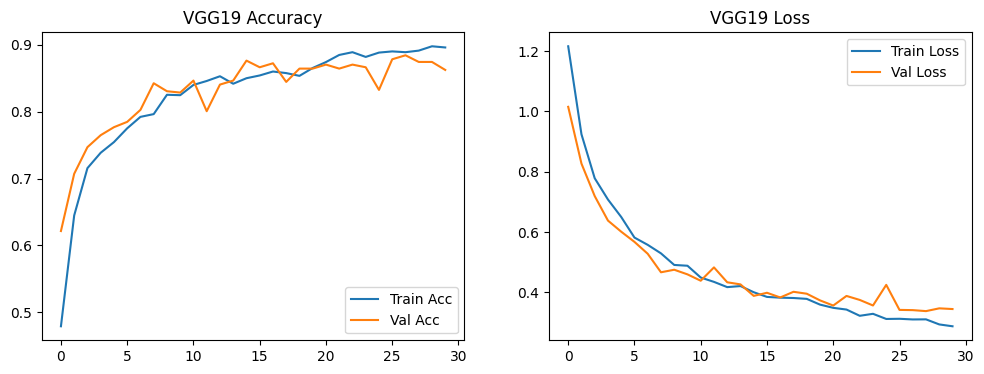

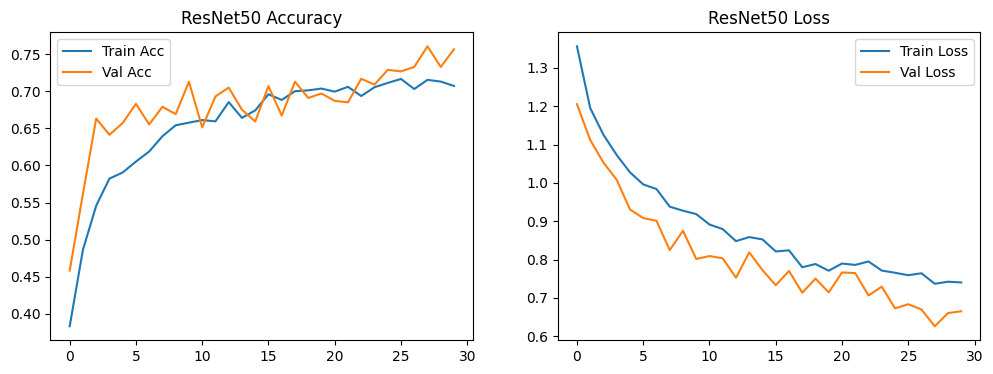

In [21]:
def plot_history(history, model_name):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Train Acc')
    plt.plot(val_acc, label='Val Acc')
    plt.title(f'{model_name} Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Train Loss')
    plt.plot(val_loss, label='Val Loss')
    plt.title(f'{model_name} Loss')
    plt.legend()
    plt.show()

plot_history(vgg_history, 'VGG19')
plot_history(resnet_history, 'ResNet50')


#### Final Accuracy Comparison of All Models

In [22]:
print(f"\nSummary:")
print(f"Custom CNN - Accuracy: {test_acc:.4f}")
print(f"VGG19     - Accuracy: {vgg_test_acc:.4f}")
print(f"ResNet50  - Accuracy: {resnet_test_acc:.4f}")



Summary:
Custom CNN - Accuracy: 0.9309
VGG19     - Accuracy: 0.8740
ResNet50  - Accuracy: 0.7358


In [29]:
model.save("Custom_model.h5")
vgg_model.save("VGG19_model.h5")
resnet_model.save("RESNET_model.h5")

## Conclusion

In this project, I developed and evaluated deep learning models to classify brain MRI images into four categories: Glioma, Meningioma, Pituitary, and No Tumor. Among the models tested—Custom CNN, VGG19, and ResNet50—my Custom CNN model achieved the highest accuracy, outperforming the pretrained architectures. This indicates that a carefully designed custom model can be more effective for specific datasets, especially in domain-specific applications like medical imaging. I also deployed the final model using Streamlit to create an interactive web application that enables real-time tumor classification, highlighting the practical applicability of deep learning in healthcare diagnostics.
